## NEM STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nem=pd.read_csv('../stock_data/nem.csv') ## so it can be small letter. This is cool.
nem=nem.drop(columns=['high_price','low_price'])
nem.rename(columns={'trade_date':'date'},inplace=True)
nem['date']=pd.to_datetime(nem['date'])
nem['month']=nem['date'].dt.month
nem['quarter']=nem['date'].dt.quarter
nem['year']=nem['date'].dt.year

nem

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,81315,NEM,2018-09-11,3.10,3.10,2210675,2026-04-08T03:07:53.572062+00:00,9,3,2018
1,81417,NEM,2018-09-12,3.00,3.00,1811521,2026-04-08T03:07:56.190409+00:00,9,3,2018
2,81519,NEM,2018-09-13,2.98,2.98,3240979,2026-04-08T03:07:58.529226+00:00,9,3,2018
3,81621,NEM,2018-09-14,2.99,2.99,1491674,2026-04-08T03:08:00.944137+00:00,9,3,2018
4,81723,NEM,2018-09-17,3.00,3.00,290459,2026-04-08T03:08:05.572353+00:00,9,3,2018
...,...,...,...,...,...,...,...,...,...,...
1851,298105,NEM,2026-07-13,28.00,28.00,413746,2026-07-13T15:10:02.995074+00:00,7,3,2026
1852,298543,NEM,2026-07-14,28.00,28.00,223648,2026-07-14T15:10:03.094441+00:00,7,3,2026
1853,298981,NEM,2026-07-15,28.00,28.00,497718,2026-07-15T15:10:03.078609+00:00,7,3,2026
1854,299419,NEM,2026-07-16,28.00,28.00,188844,2026-07-16T15:10:03.113936+00:00,7,3,2026


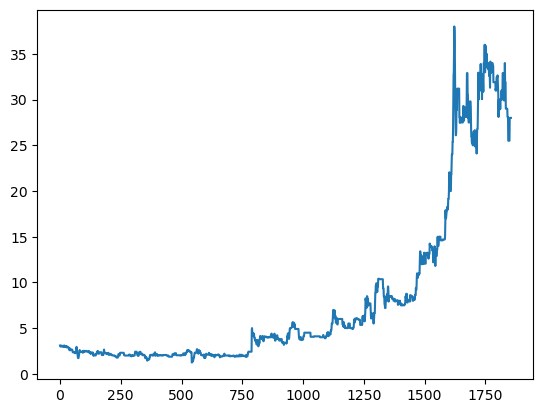

In [2]:
import matplotlib.pyplot as plt

plt.plot(nem['close_price'])
plt.show()

In [3]:
nem_end_month_df = (
    nem
    .sort_values("date")
    .groupby(nem["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nem_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,82641,NEM,2018-09-28,3.00,3.00,210149,2026-04-08T03:08:29.283021+00:00,9,3,2018
1,84783,NEM,2018-10-31,2.90,2.90,1419000,2026-04-08T03:09:32.658485+00:00,10,4,2018
2,86823,NEM,2018-11-30,2.35,2.35,628841,2026-04-08T03:10:32.706086+00:00,11,4,2018
3,88349,NEM,2018-12-31,2.70,2.70,145288647,2026-04-08T03:11:26.963749+00:00,12,4,2018
4,90389,NEM,2019-01-31,2.39,2.39,152702,2026-04-08T03:12:45.452606+00:00,1,1,2019
...,...,...,...,...,...,...,...,...,...,...
90,35342,NEM,2026-03-31,31.90,31.90,1903689,2026-03-31T15:00:02.085058+00:00,3,1,2026
91,281168,NEM,2026-04-30,30.55,30.55,3168341,2026-04-30T15:00:02.170664+00:00,4,2,2026
92,284234,NEM,2026-05-29,32.90,32.90,286485,2026-05-29T15:00:02.455558+00:00,5,2,2026
93,294162,NEM,2026-06-30,28.10,28.10,799974,2026-06-30T15:10:03.08168+00:00,6,2,2026


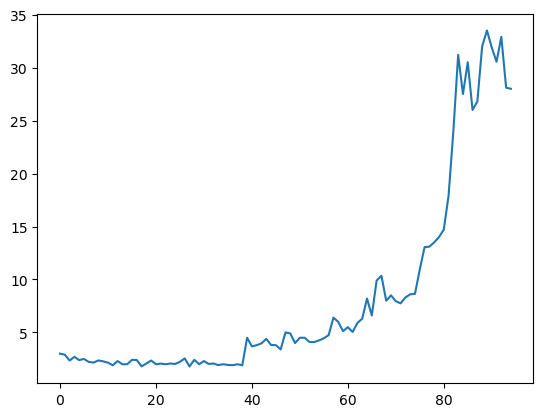

In [4]:
plt.plot(nem_end_month_df['close_price'])
plt.show()

In [5]:
nem_end_month_df['returns']=nem_end_month_df['close_price'].pct_change()*100
nem_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,82641,NEM,2018-09-28,3.00,3.00,210149,2026-04-08T03:08:29.283021+00:00,9,3,2018,NaN
1,84783,NEM,2018-10-31,2.90,2.90,1419000,2026-04-08T03:09:32.658485+00:00,10,4,2018,-3.333333
2,86823,NEM,2018-11-30,2.35,2.35,628841,2026-04-08T03:10:32.706086+00:00,11,4,2018,-18.965517
3,88349,NEM,2018-12-31,2.70,2.70,145288647,2026-04-08T03:11:26.963749+00:00,12,4,2018,14.893617
4,90389,NEM,2019-01-31,2.39,2.39,152702,2026-04-08T03:12:45.452606+00:00,1,1,2019,-11.481481
...,...,...,...,...,...,...,...,...,...,...,...
90,35342,NEM,2026-03-31,31.90,31.90,1903689,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.776119
91,281168,NEM,2026-04-30,30.55,30.55,3168341,2026-04-30T15:00:02.170664+00:00,4,2,2026,-4.231975
92,284234,NEM,2026-05-29,32.90,32.90,286485,2026-05-29T15:00:02.455558+00:00,5,2,2026,7.692308
93,294162,NEM,2026-06-30,28.10,28.10,799974,2026-06-30T15:10:03.08168+00:00,6,2,2026,-14.589666


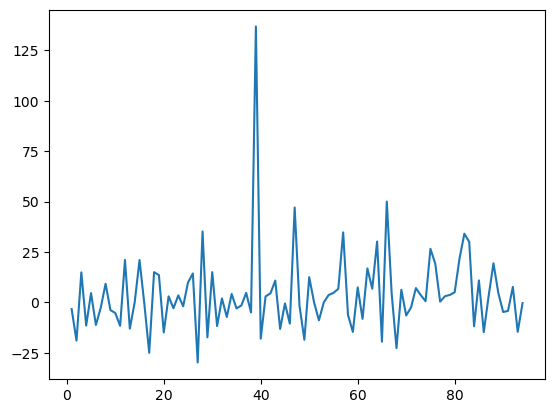

In [6]:
plt.plot(nem_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nem_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-12.134535342813182, 1.7055253410368814e-22, 0, 93, {'1%': -3.502704609582561, '5%': -2.8931578098779522, '10%': -2.583636712914788}, 724.292802693956)
stationary


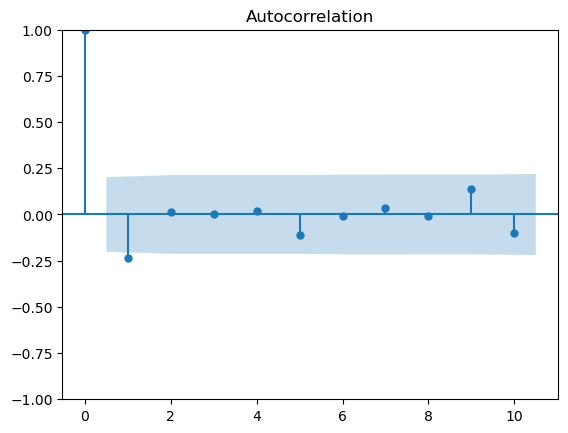

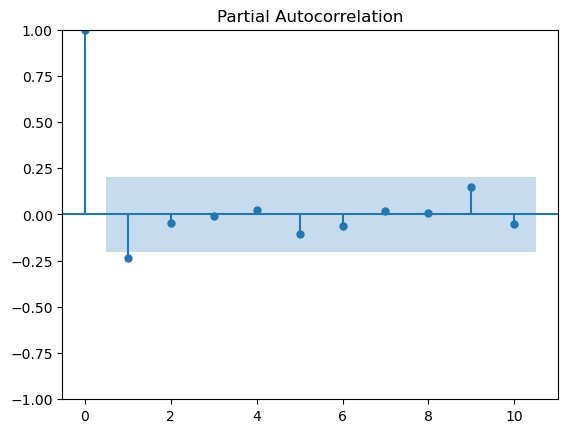

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nem_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nem_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nem_end_month_df['close_price'][:-10]
test=nem_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -143.8574392116969]
[0, 0, 0, 0, 0, 1, -79.44494544116867]
[0, 0, 0, 0, 0, 2, -57.34201679690545]
[0, 0, 0, 0, 1, 0, -44.811900345082094]
[0, 0, 0, 0, 1, 1, -36.58638076889515]
[0, 0, 0, 0, 1, 2, -35.36593765527296]
[0, 0, 0, 0, 2, 0, -26.62068896734687]
[0, 0, 0, 0, 2, 1, -26.625374107722838]
[0, 0, 0, 0, 2, 2, -26.62349399329723]
[0, 0, 0, 1, 0, 0, -51.72628274546934]
[0, 0, 0, 1, 0, 1, -43.178565561397875]
[0, 0, 0, 1, 0, 2, -43.20380355228458]
[0, 0, 0, 1, 1, 0, -32.152231115304424]
[0, 0, 0, 1, 1, 1, -32.24184672858858]
[0, 0, 0, 1, 1, 2, -32.54357869200315]
[0, 0, 0, 1, 2, 0, -26.600349866819986]
[0, 0, 0, 1, 2, 1, -27.501522237826197]
[0, 0, 0, 1, 2, 2, -27.924113325131675]
[0, 0, 0, 2, 0, 0, -41.75506927535535]
[0, 0, 0, 2, 0, 1, -43.250986583088874]
[0, 0, 0, 2, 0, 2, -43.78787936140686]
[0, 0, 0, 2, 1, 0, -32.11263987509037]
[0, 0, 0, 2, 1, 1, -32.948238270142824]
[0, 0, 0, 2, 1, 2, -33.16322585143744]
[0, 0, 0, 2, 2, 0, -26.918180536449192]
[0, 0, 0, 2, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-143.857439
27,0,0,1,0,0,0,-135.403520
54,0,0,2,0,0,0,-130.671097
726,2,2,2,2,2,0,-128.294430
718,2,2,2,1,2,1,-123.397890
...,...,...,...,...,...,...,...
248,1,0,0,0,1,2,-0.359592
419,1,2,0,1,1,2,-0.266663
409,1,2,0,0,1,1,-0.261192
418,1,2,0,1,1,1,-0.200200


In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nem_end_month_df['returns'].dropna()[:-10]
test=nem_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.004737181647261224]
[0, 0, 0, 0, 0, 1, -0.06688015792201307]
[0, 0, 0, 0, 0, 2, -0.3330684440056231]
[0, 0, 0, 0, 1, 0, -2.3244448763299372]
[0, 0, 0, 0, 1, 1, -1.1713747214383097]
[0, 0, 0, 0, 1, 2, -2.018207617718992]
[0, 0, 0, 0, 2, 0, -11.148580675059588]
[0, 0, 0, 0, 2, 1, -3.3775130268613722]
[0, 0, 0, 0, 2, 2, -4.170381742120299]
[0, 0, 0, 1, 0, 0, -0.09203530329447274]
[0, 0, 0, 1, 0, 1, -0.09422224280086855]
[0, 0, 0, 1, 0, 2, -1.3551150648796395]
[0, 0, 0, 1, 1, 0, -2.465178437451446]
[0, 0, 0, 1, 1, 1, -1.6403627539801748]
[0, 0, 0, 1, 1, 2, -2.6803216987617033]
[0, 0, 0, 1, 2, 0, -4.195874766086511]
[0, 0, 0, 1, 2, 1, -3.6021312229376807]
[0, 0, 0, 1, 2, 2, -4.823308568379411]
[0, 0, 0, 2, 0, 0, -0.10665219912001422]
[0, 0, 0, 2, 0, 1, -0.7160763905334551]
[0, 0, 0, 2, 0, 2, -1.7250474494277412]
[0, 0, 0, 2, 1, 0, -2.568245500866728]
[0, 0, 0, 2, 1, 1, -1.8282096630153388]
[0, 0, 0, 2, 1, 2, -3.5520748461649694]
[0, 0, 0, 2, 2, 0, -11.058184229256398]


In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
481,1,2,2,2,1,1,-539352.998541
177,0,2,0,1,2,0,-2867.941731
174,0,2,0,1,1,0,-1280.673503
178,0,2,0,1,2,1,-1260.701868
165,0,2,0,0,1,0,-992.224824
...,...,...,...,...,...,...,...
270,1,0,1,0,0,0,0.057345
486,2,0,0,0,0,0,0.062839
333,1,1,0,1,0,0,0.068818
325,1,1,0,0,0,1,0.077171


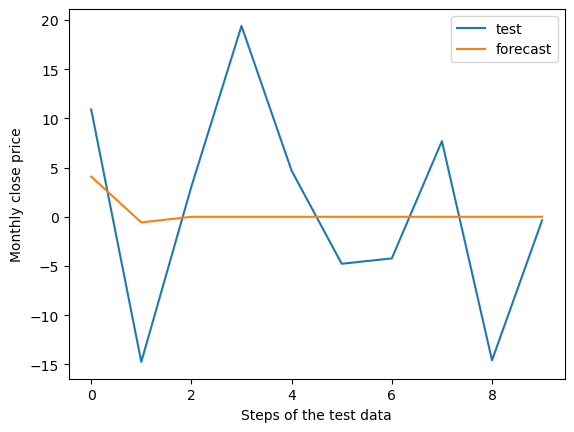

r2_score:  0.07985005550180191
rmse:  9.841021973137154
description:  count     94.000000
mean       3.972138
std       20.434149
min      -29.803922
25%       -6.415441
50%        2.475737
75%        9.703977
max      136.842105
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=nem_end_month_df['returns'].dropna()[:-10]
y_test=nem_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,0,2), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nem_end_month_df.returns.dropna().describe())

Very horrible. No good model
